# Sistem Klasifikasi Obesitas

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 : Bagaimana Distribusi Kolom Weight_Status Sebagai Target ?
- Pertanyaan 2 : Hubungan Antara Usia dan Weight_Status ?
- Pertanyaan 3 : Apa Fitur yang Paling SIgnifikan dengan Target ?

## Dictionary

| Kolom                          |Deskripsi                                |
| ------------------------------ | ---------------------------------------- |
| Gender                         | Jenis kelamin responden                  |
| Age                            | Umur responden                           |
| Height                         | Tinggi badan responden (meter)           |
| Weight                         | Berat badan responden (kg)               |
| family_history_with_overweight | Riwayat keluarga dengan overweight       |
| FAVC                           | Sering mengonsumsi makanan tinggi kalori |
| FCVC                           | Frekuensi konsumsi sayur                 |
| NCP                            | Jumlah makan utama per hari              |
| CAEC                           | Kebiasaan makan di antara waktu makan    |
| SMOKE                          | Kebiasaan merokok                        |
| CH2O                           | Konsumsi air harian                      |
| SCC                            | Monitoring konsumsi kalori               |
| FAF                            | Frekuensi aktivitas fisik                |
| TUE                            | Waktu penggunaan perangkat teknologi     |
| CALC                           | Konsumsi alkohol                         |
| MTRANS                         | Transportasi utama                       |
| Weight_Status                  | Target klasifikasi status berat badan    |


## Data Wrangling

### Gathering Data

*Import Library*

In [46]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (15, 20)

pd.set_option('display.precision', 3)
pd.set_option('display.max_columns', 50)

np.set_printoptions(precision=3)

*Loading Data*

In [47]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')

In [48]:
# Melihat 5 data teratas
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [49]:
# # Melihat 5 data terbawah
df.tail()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
2106,20.977,Female,1.711,131.409,Sometimes,yes,3.0,3.0,no,no,1.728,yes,1.676,0.906,Sometimes,Public_Transportation,Obesity_Type_III
2107,21.983,Female,1.749,133.743,Sometimes,yes,3.0,3.0,no,no,2.005,yes,1.341,0.599,Sometimes,Public_Transportation,Obesity_Type_III
2108,22.524,Female,1.752,133.689,Sometimes,yes,3.0,3.0,no,no,2.054,yes,1.414,0.646,Sometimes,Public_Transportation,Obesity_Type_III
2109,24.362,Female,1.739,133.347,Sometimes,yes,3.0,3.0,no,no,2.852,yes,1.139,0.586,Sometimes,Public_Transportation,Obesity_Type_III
2110,23.665,Female,1.739,133.473,Sometimes,yes,3.0,3.0,no,no,2.864,yes,1.026,0.714,Sometimes,Public_Transportation,Obesity_Type_III


####

### Assesing Data

*Melihat informasi umum dan bentuk data*

In [50]:
# Melihat informasi umum dan tipe data
df.info()

print("="*50)

# Melihat bentuk data
df.shape
baris, kolom = df.shape
print(f"Jumlah baris : {baris}")
print(f"Jumlah Kolom : {kolom}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   object 
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   object 
 12  FAF                             21

*Mengecek Missing Value*

In [51]:
# Mengecek missing value di setiap kolom
print("[MISSING VALUES]")
df.isnull().sum()


[MISSING VALUES]


Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

*Mengecek Data Duplikat*

In [52]:
# Menghitung jumlah data duplikat
print(f"Total data duplikat: {df.duplicated().sum()}")

Total data duplikat: 24


*Mengecek Statistik Deskriptif Dataset*

In [53]:
df.describe(include='all')

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
count,2111.000,2111,2111.000,2111.000,2111,2111,2111.000,2111.000,2111,2111,2111.000,2111,2111.000,2111.000,2111,2111,2111
unique,NaN,2,NaN,NaN,4,2,NaN,NaN,2,2,NaN,2,NaN,NaN,4,5,7
top,NaN,Male,NaN,NaN,Sometimes,yes,NaN,NaN,no,no,NaN,yes,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,NaN,1068,NaN,NaN,1401,1866,NaN,NaN,2015,2067,NaN,1726,NaN,NaN,1765,1580,351
mean,24.313,NaN,1.702,86.586,NaN,NaN,2.419,2.686,NaN,NaN,2.008,NaN,1.010,0.658,NaN,NaN,NaN
std,6.346,NaN,0.093,26.191,NaN,NaN,0.534,0.778,NaN,NaN,0.613,NaN,0.851,0.609,NaN,NaN,NaN
min,14.000,NaN,1.450,39.000,NaN,NaN,1.000,1.000,NaN,NaN,1.000,NaN,0.000,0.000,NaN,NaN,NaN
25%,19.947,NaN,1.630,65.473,NaN,NaN,2.000,2.659,NaN,NaN,1.585,NaN,0.125,0.000,NaN,NaN,NaN
50%,22.778,NaN,1.700,83.000,NaN,NaN,2.386,3.000,NaN,NaN,2.000,NaN,1.000,0.625,NaN,NaN,NaN
75%,26.000,NaN,1.768,107.431,NaN,NaN,3.000,3.000,NaN,NaN,2.477,NaN,1.667,1.000,NaN,NaN,NaN


## Data Cleaning

*Menghilangkan Data Duplikat*

In [54]:
# Menghapus Seluruh Data Duplikat Langsung pada df
df.drop_duplicates(inplace=True)

In [55]:
# Mengecek jumlah data duplikat
print(f"Total data duplikat: {df.duplicated().sum()}")

Total data duplikat: 0


*Menyesuaikan Tipe Data*

In [56]:
# Mengubah semua kolom numerik kecuali 'Height' dan 'Weight' menjadi integer untuk menjaga konsistensi data
for column in df.columns:
    # Mengecualikan kolom Height dan Weight
    if df[column].dtype == "float64" and column not in ["Height", "Weight"]:
        # Bulatkan dulu (round), baru jadikan integer
        df[column] = df[column].round().astype('int64')

In [57]:
# Mengecek Kembali Tipe Data
df.dtypes

Age                                 int64
Gender                             object
Height                            float64
Weight                            float64
CALC                               object
FAVC                               object
FCVC                                int64
NCP                                 int64
SCC                                object
SMOKE                              object
CH2O                                int64
family_history_with_overweight     object
FAF                                 int64
TUE                                 int64
CAEC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

## Feature Engineering

*Pembuatan fungsi untuk Feature Engineering*

In [58]:
def Feature_Engineering(df):
    # Pemetaan kolom target dari yang awalnya 7 menjadi 4 kelas baru
    mapping_obesitas = {
        'Insufficient_Weight': 'Underweight',
        'Normal_Weight': 'Normal',
        'Overweight_Level_I': 'Overweight',
        'Overweight_Level_II': 'Overweight',
        'Obesity_Type_I': 'Obesity',
        'Obesity_Type_II': 'Obesity',
        'Obesity_Type_III': 'Obesity'
    }
    
    # 2. Mapping target ke kolom baru
    df['Weight_Status'] = df['NObeyesdad'].replace(mapping_obesitas)
    
    # 3. Pembuatan fitur baru (BMI & Water Intake Ratio)
    # Pastikan Height dalam Meter
    df['BMI'] = df['Weight'] / (df['Height']**2)
    df['Water_Intake_Per_Kg'] = df['CH2O'] / df['Weight']
    
    return df

# Eksekusi fungsi
df = Feature_Engineering(df)

In [59]:
# Cek distribusi target baru
print("Distribusi Target Baru (4 Kelas):")
print(df['Weight_Status'].value_counts())
print("=" * 50)

# Cek korelasi dasar fitur baru
print("\nStatistik Fitur Baru:")
print(df[['BMI', 'Water_Intake_Per_Kg']].describe())
print("=" * 50)

# Tampilkan sample komparasi sebelum kolom lama di-drop
print("\nSample Komparasi (Target Lama vs Baru):")
print(df[['NObeyesdad', 'Weight_Status', 'BMI']].sample(5))
print("=" * 50)

# Drop kolom target lama setelah dipastikan bener
df.drop(columns=['NObeyesdad'], inplace=True, errors='ignore')

Distribusi Target Baru (4 Kelas):
Weight_Status
Obesity        972
Overweight     566
Normal         282
Underweight    267
Name: count, dtype: int64

Statistik Fitur Baru:
            BMI  Water_Intake_Per_Kg
count  2087.000             2087.000
mean     29.766                0.025
std       8.025                0.011
min      12.999                0.007
25%      24.369                0.017
50%      28.896                0.024
75%      36.096                0.031
max      50.812                0.070

Sample Komparasi (Target Lama vs Baru):
               NObeyesdad Weight_Status     BMI
556   Insufficient_Weight   Underweight  16.028
2015     Obesity_Type_III       Obesity  39.419
182   Insufficient_Weight   Underweight  18.424
2033     Obesity_Type_III       Obesity  41.385
6           Normal_Weight        Normal  24.444


In [60]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

# --- 1. CLEANING ---
kategori_cols = ['CALC', 'CAEC', 'Gender', 'FAVC', 'SCC', 'SMOKE', 
                 'family_history_with_overweight', 'MTRANS', 'Weight_Status']
for col in kategori_cols:
    if col in df.columns:
        df[col] = df[col].str.strip()

# --- 2. LOGICAL ORDINAL MAPPING (RISK-BASED) ---

# MTRANS: Aktivitas Fisik Tinggi (0) ke Rendah (4)
urutan_mtrans = ['Bike', 'Walking', 'Public_Transportation', 'Motorbike', 'Automobile']

# CAEC & CALC: Konsumsi Rendah (0) ke Tinggi (3)
urutan_frekuensi = ['no', 'Sometimes', 'Frequently', 'Always']

# Target: Berat Badan Rendah (0) ke Tinggi (3)
urutan_target = ['Underweight', 'Normal', 'Overweight', 'Obesity']

# Eksekusi mapping
ord_enc = OrdinalEncoder(categories=[urutan_mtrans, urutan_frekuensi, urutan_frekuensi])
df[['MTRANS_Num', 'CAEC_Num', 'CALC_Num']] = ord_enc.fit_transform(df[['MTRANS', 'CAEC', 'CALC']])

ord_target = OrdinalEncoder(categories=[urutan_target])
df['Weight_Status_Num'] = ord_target.fit_transform(df[['Weight_Status']])

# --- 3. BINARY MAPPING (0=No, 1=Yes) ---
# Secara otomatis: 0 = Tidak ada faktor/kebiasaan, 1 = Ada faktor/kebiasaan
binary_map = {'no': 0, 'yes': 1}
kolom_yes_no = ['FAVC', 'SCC', 'SMOKE', 'family_history_with_overweight']

for col in kolom_yes_no:
    df[f'{col}_Num'] = df[col].map(binary_map)

# Gender: Male=0, Female=1 (Netral, tapi harus numerik)
df['Gender_Num'] = df['Gender'].map({'Male': 0, 'Female': 1})

# --- 4. CLEANUP (Hapus kolom _Num yang duplikat dengan fitur asli numerik) ---
cols_drop = [c for c in df.columns if c.endswith('_Num') and c.replace('_Num', '') in ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']]
df.drop(columns=cols_drop, errors='ignore', inplace=True)

# --- 5. VALIDASI ---
print("--- CHECKPOINT LOGIKA RISIKO ---")
print(f"MTRANS mapping: {urutan_mtrans}")
print(f"Habit mapping: {urutan_frekuensi}")
print(f"Binary mapping: {binary_map}")

--- CHECKPOINT LOGIKA RISIKO ---
MTRANS mapping: ['Bike', 'Walking', 'Public_Transportation', 'Motorbike', 'Automobile']
Habit mapping: ['no', 'Sometimes', 'Frequently', 'Always']
Binary mapping: {'no': 0, 'yes': 1}


In [61]:
print(df['MTRANS'].value_counts())

MTRANS
Public_Transportation    1558
Automobile                456
Walking                    55
Motorbike                  11
Bike                        7
Name: count, dtype: int64


In [62]:
df.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,Weight_Status,BMI,Water_Intake_Per_Kg,MTRANS_Num,CAEC_Num,CALC_Num,Weight_Status_Num,FAVC_Num,SCC_Num,SMOKE_Num,family_history_with_overweight_Num,Gender_Num
0,21,Female,1.62,64.0,no,no,2,3,no,no,2,yes,0,1,Sometimes,Public_Transportation,Normal,24.387,0.031,2.0,1.0,0.0,1.0,0,0,0,1,1
1,21,Female,1.52,56.0,Sometimes,no,3,3,yes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal,24.238,0.054,2.0,1.0,1.0,1.0,0,1,1,1,1
2,23,Male,1.80,77.0,Frequently,no,2,3,no,no,2,yes,2,1,Sometimes,Public_Transportation,Normal,23.765,0.026,2.0,1.0,2.0,1.0,0,0,0,1,0
3,27,Male,1.80,87.0,Frequently,no,3,3,no,no,2,no,2,0,Sometimes,Walking,Overweight,26.852,0.023,1.0,1.0,2.0,2.0,0,0,0,0,0
4,22,Male,1.78,89.8,Sometimes,no,2,1,no,no,2,no,0,0,Sometimes,Public_Transportation,Overweight,28.342,0.022,2.0,1.0,1.0,2.0,0,0,0,0,0


## EDA

*Hubungan Fitur Numeric dengan Target*

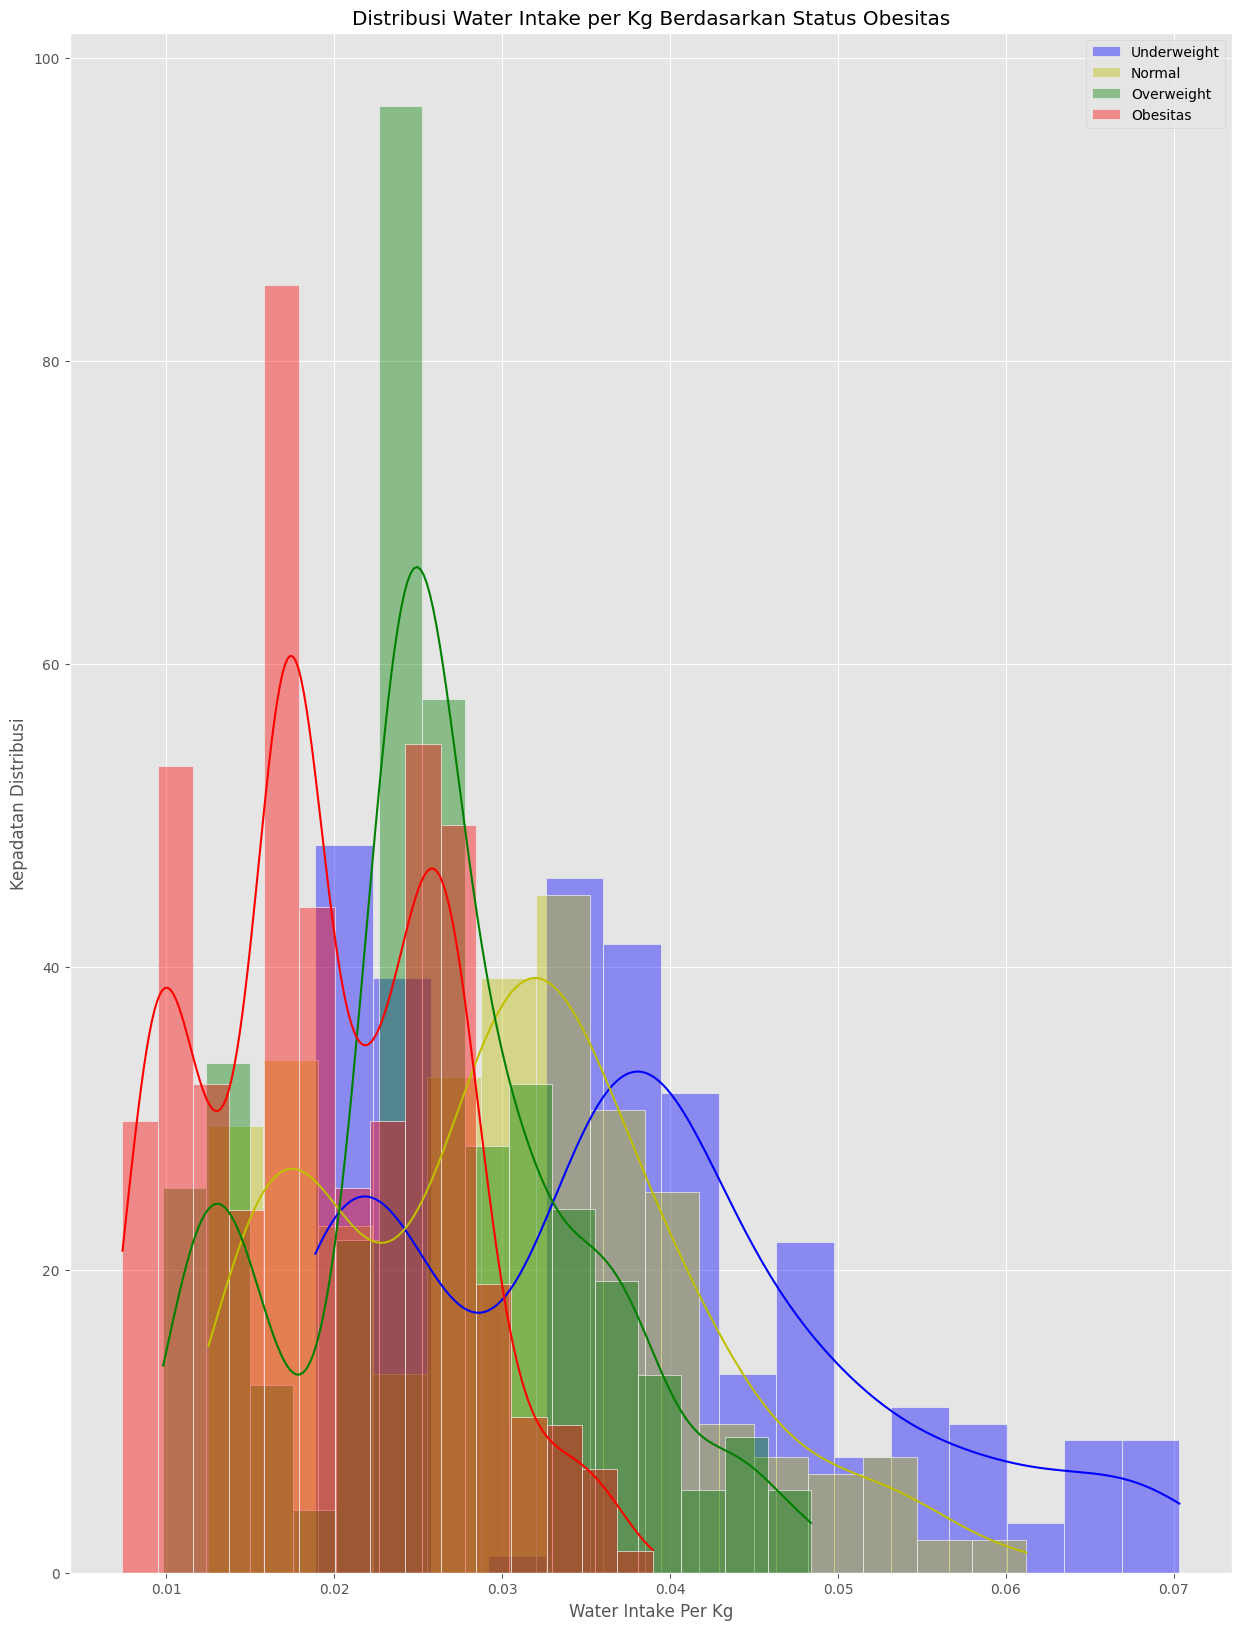

In [63]:
    

# Ganti distplot jadi histplot, tambah kde=True buat munculin garis kurvanya
# Bins diset ke 15 (jumlah keranjangnya), bukan pakai list rentang yang kebesaran
sns.histplot(df.Water_Intake_Per_Kg[df.Weight_Status == 'Underweight'], bins=15, color="b", label="Underweight", kde=True, stat="density", alpha=0.4)
sns.histplot(df.Water_Intake_Per_Kg[df.Weight_Status == 'Normal'], bins=15, color="y", label="Normal", kde=True, stat="density", alpha=0.4)
sns.histplot(df.Water_Intake_Per_Kg[df.Weight_Status == 'Overweight'], bins=15, color="g", label="Overweight", kde=True, stat="density", alpha=0.4)
sns.histplot(df.Water_Intake_Per_Kg[df.Weight_Status == 'Obesity'], bins=15, color="r", label="Obesitas", kde=True, stat="density", alpha=0.4)

plt.title('Distribusi Water Intake per Kg Berdasarkan Status Obesitas')
plt.xlabel('Water Intake Per Kg')
plt.ylabel('Kepadatan Distribusi')
plt.legend()
plt.show()

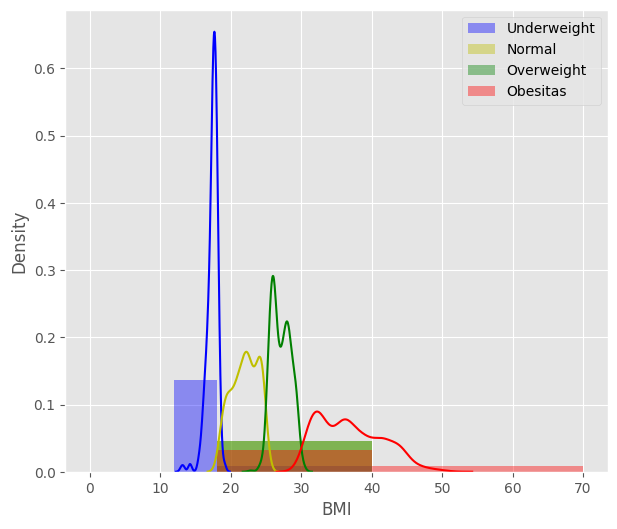

In [64]:
# Hubungan BMI dengan Weight_Status
plt.figure(figsize=(7, 6))
sns.distplot(df.BMI[df.Weight_Status == 'Underweight'], bins=[0, 5, 12, 18, 40, 70], color="b",label="Underweight" )
sns.distplot(df.BMI[df.Weight_Status == 'Normal'], bins=[0, 5, 12, 18, 40, 70], color="y", label="Normal")
sns.distplot(df.BMI[df.Weight_Status == 'Overweight'], bins=[0, 5, 12, 18, 40, 70], color="g", label="Overweight")
sns.distplot(df.BMI[df.Weight_Status == 'Obesity'], bins=[0, 5, 12, 18, 40, 70], color="r", label="Obesitas")
plt.legend()



In [65]:
# Tambahin 'count' buat ngitung jumlah orang di tiap kelas
cek_rentang_bmi = df.groupby('Weight_Status')['BMI'].agg(['count', 'min', 'mean', 'max']).reset_index()

# Urutin dari rata-rata BMI terkecil ke terbesar biar enak dibaca
cek_rentang_bmi = cek_rentang_bmi.sort_values(by='mean')

# Ganti nama kolom biar lebih rapi pas ditampilin di laporan
cek_rentang_bmi.rename(columns={'count': 'Jumlah_Data', 'min': 'BMI_Min', 'mean': 'BMI_Rata2', 'max': 'BMI_Max'}, inplace=True)

print(cek_rentang_bmi)

  Weight_Status  Jumlah_Data  BMI_Min  BMI_Rata2  BMI_Max
3   Underweight          267   12.999     17.391   19.082
0        Normal          282   18.491     22.008   24.913
2    Overweight          566   22.827     27.114   30.363
1       Obesity          972   29.912     36.960   50.812


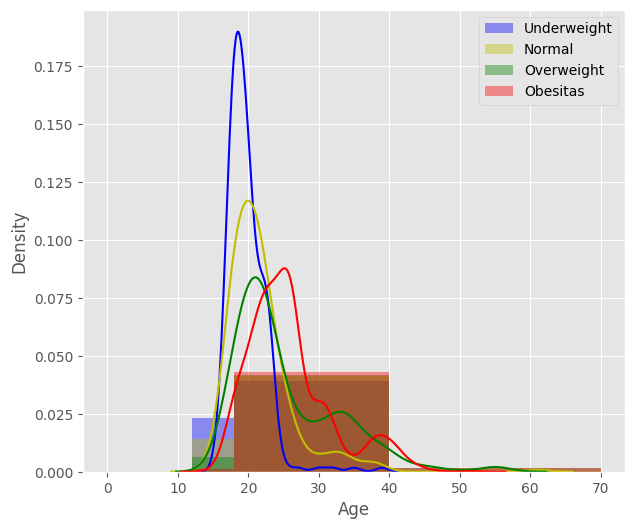

In [66]:
# Hubungan Age dengan Weight_Status
plt.figure(figsize=(7, 6))
sns.distplot(df.Age[df.Weight_Status == 'Underweight'], bins=[0, 5, 12, 18, 40, 70], color="b",label="Underweight" )
sns.distplot(df.Age[df.Weight_Status == 'Normal'], bins=[0, 5, 12, 18, 40, 70], color="y", label="Normal")
sns.distplot(df.Age[df.Weight_Status == 'Overweight'], bins=[0, 5, 12, 18, 40, 70], color="g", label="Overweight")
sns.distplot(df.Age[df.Weight_Status == 'Obesity'], bins=[0, 5, 12, 18, 40, 70], color="r", label="Obesitas")
plt.legend()



*insight*
- Obesity dan Overweight cenderung dialami oleh usia diatas 25 tahun

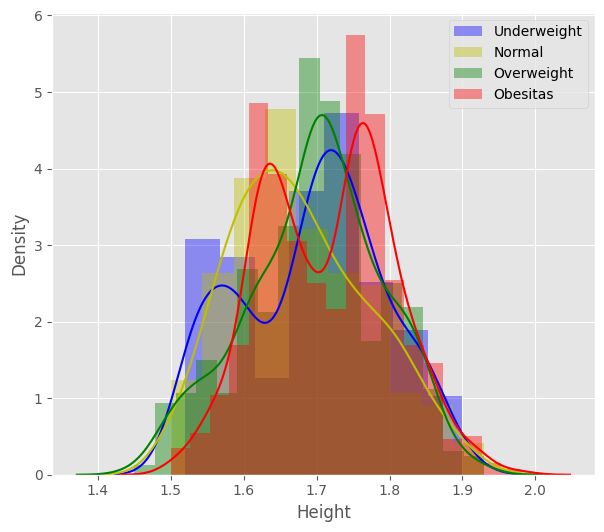

In [67]:
plt.figure(figsize=(7, 6))
sns.distplot(df.Height[df.Weight_Status == 'Underweight'], color="b", label="Underweight")
sns.distplot(df.Height[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.Height[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.Height[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()


*Insight*
- Tinggi badan antar kategori Weight_status memiliki distribusi yang cukup mirip.
- Tidak terdapat perbedaan signifikan tinggi badan pada tiap kategori obesitas.

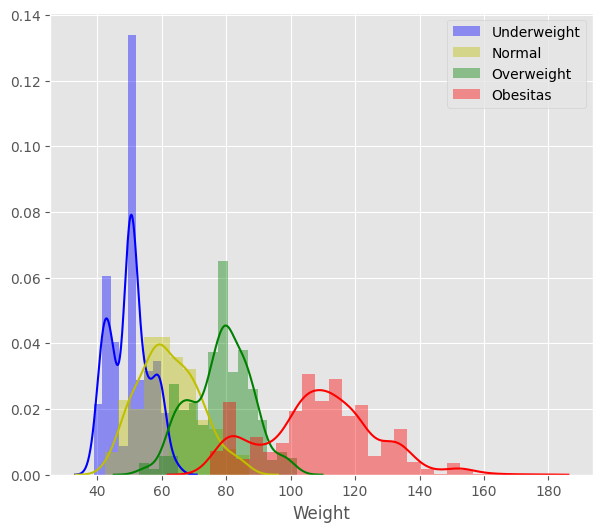

In [68]:
plt.figure(figsize=(7, 6))
sns.distplot(df.Weight[df.Weight_Status == 'Underweight'], color="b", label="Underweight")
sns.distplot(df.Weight[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.Weight[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.Weight[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.ylabel('')
plt.legend()



*Insight*
- Kelompok obesitas memiliki berat badan paling tinggi dibanding kategori lain.

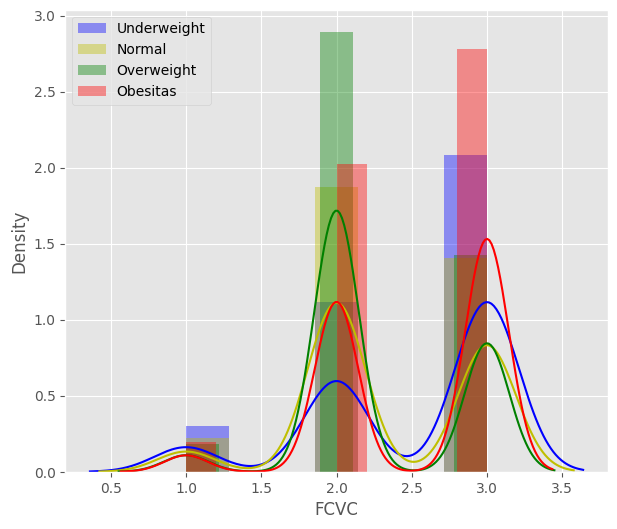

In [69]:
plt.figure(figsize=(7, 6))
sns.distplot(df.FCVC[df.Weight_Status == 'Underweight'], color="b", label="Underweight")
sns.distplot(df.FCVC[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.FCVC[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.FCVC[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()



*insight*
- Individu normal dan underweight cenderung memiliki konsumsi sayur lebih tinggi.
- Kelompok obesitas masih muncul pada tingkat konsumsi sayur rendah hingga sedang.

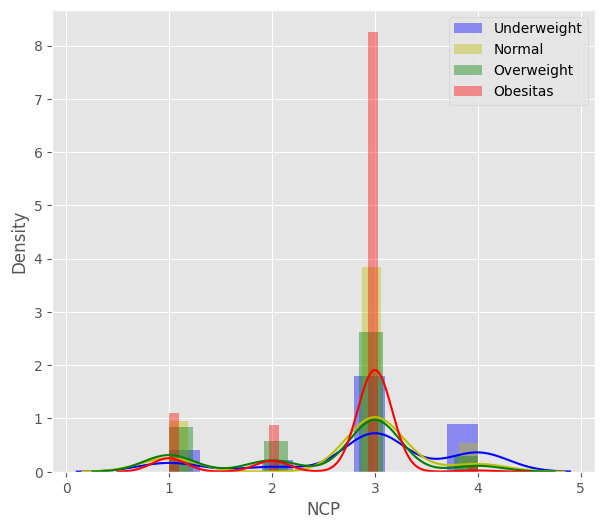

In [70]:
plt.figure(figsize=(7, 6))
sns.distplot(df.NCP[df.Weight_Status == 'Underweight'], color="b", label="Underweight")
sns.distplot(df.NCP[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.NCP[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.NCP[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()



*Insight*
- Mayoritas responden mengonsumsi sekitar 3 kali makan utama per hari.

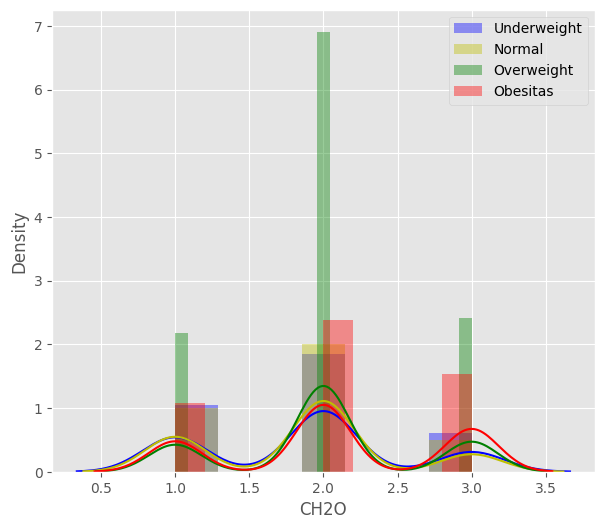

In [71]:
plt.figure(figsize=(7, 6))
sns.distplot(df.CH2O[df.Weight_Status == 'Underweight'], color="b", label="Underweight" )
sns.distplot(df.CH2O[df.Weight_Status == 'Normal'], color="y", label="Normal" )
sns.distplot(df.CH2O[df.Weight_Status == 'Overweight'], color="g", label="Overweight" )
sns.distplot(df.CH2O[df.Weight_Status == 'Obesity'], color="r", label="Obesitas" )
plt.legend()



*Insight*
- Sebagian besar responden berada pada tingkat konsumsi air sedang.
- Tidak terlihat perbedaan yang terlalu ekstrem antar kategori BMI.

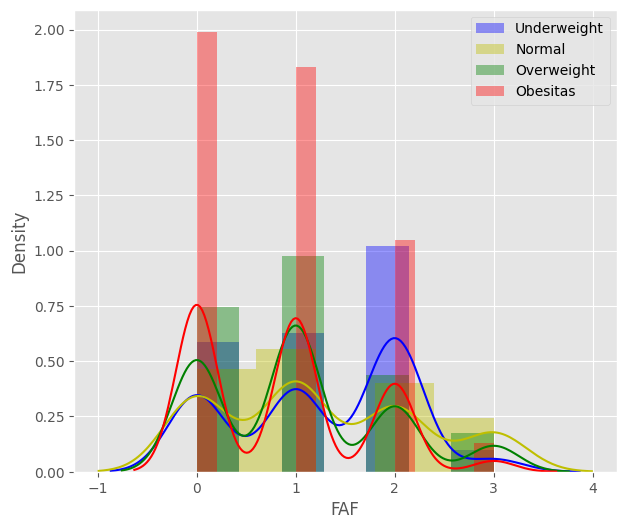

In [72]:
plt.figure(figsize=(7, 6))
sns.distplot(df.FAF[df.Weight_Status == 'Underweight'], color="b", label="Underweight" )
sns.distplot(df.FAF[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.FAF[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.FAF[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()



*Insight*
- FAF (Aktivitas Fisik) Untuk status weight nya normal dan underweight frekuensi aktivitas fisik nya lebih banyak dibndingkan status weight yang lain.

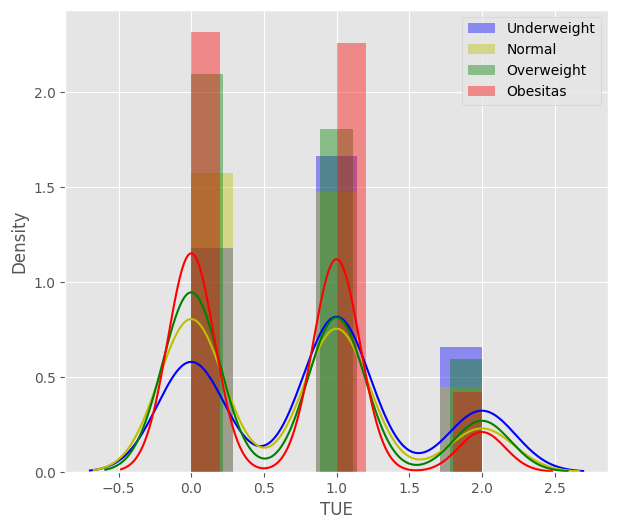

In [73]:
plt.figure(figsize=(7, 6))
sns.distplot(df.TUE[df.Weight_Status == 'Underweight'], color="b", label="Underweight" )
sns.distplot(df.TUE[df.Weight_Status == 'Normal'], color="y", label="Normal")
sns.distplot(df.TUE[df.Weight_Status == 'Overweight'], color="g", label="Overweight")
sns.distplot(df.TUE[df.Weight_Status == 'Obesity'], color="r", label="Obesitas")
plt.legend()



*Insight*
- Kelompok obesitas cenderung memiliki penggunaan teknologi lebih tinggi dibanding kategori lain.
- Individu underweight lebih banyak berada pada durasi penggunaan teknologi rendah.

*Cek Outlier di Fitur numerik*

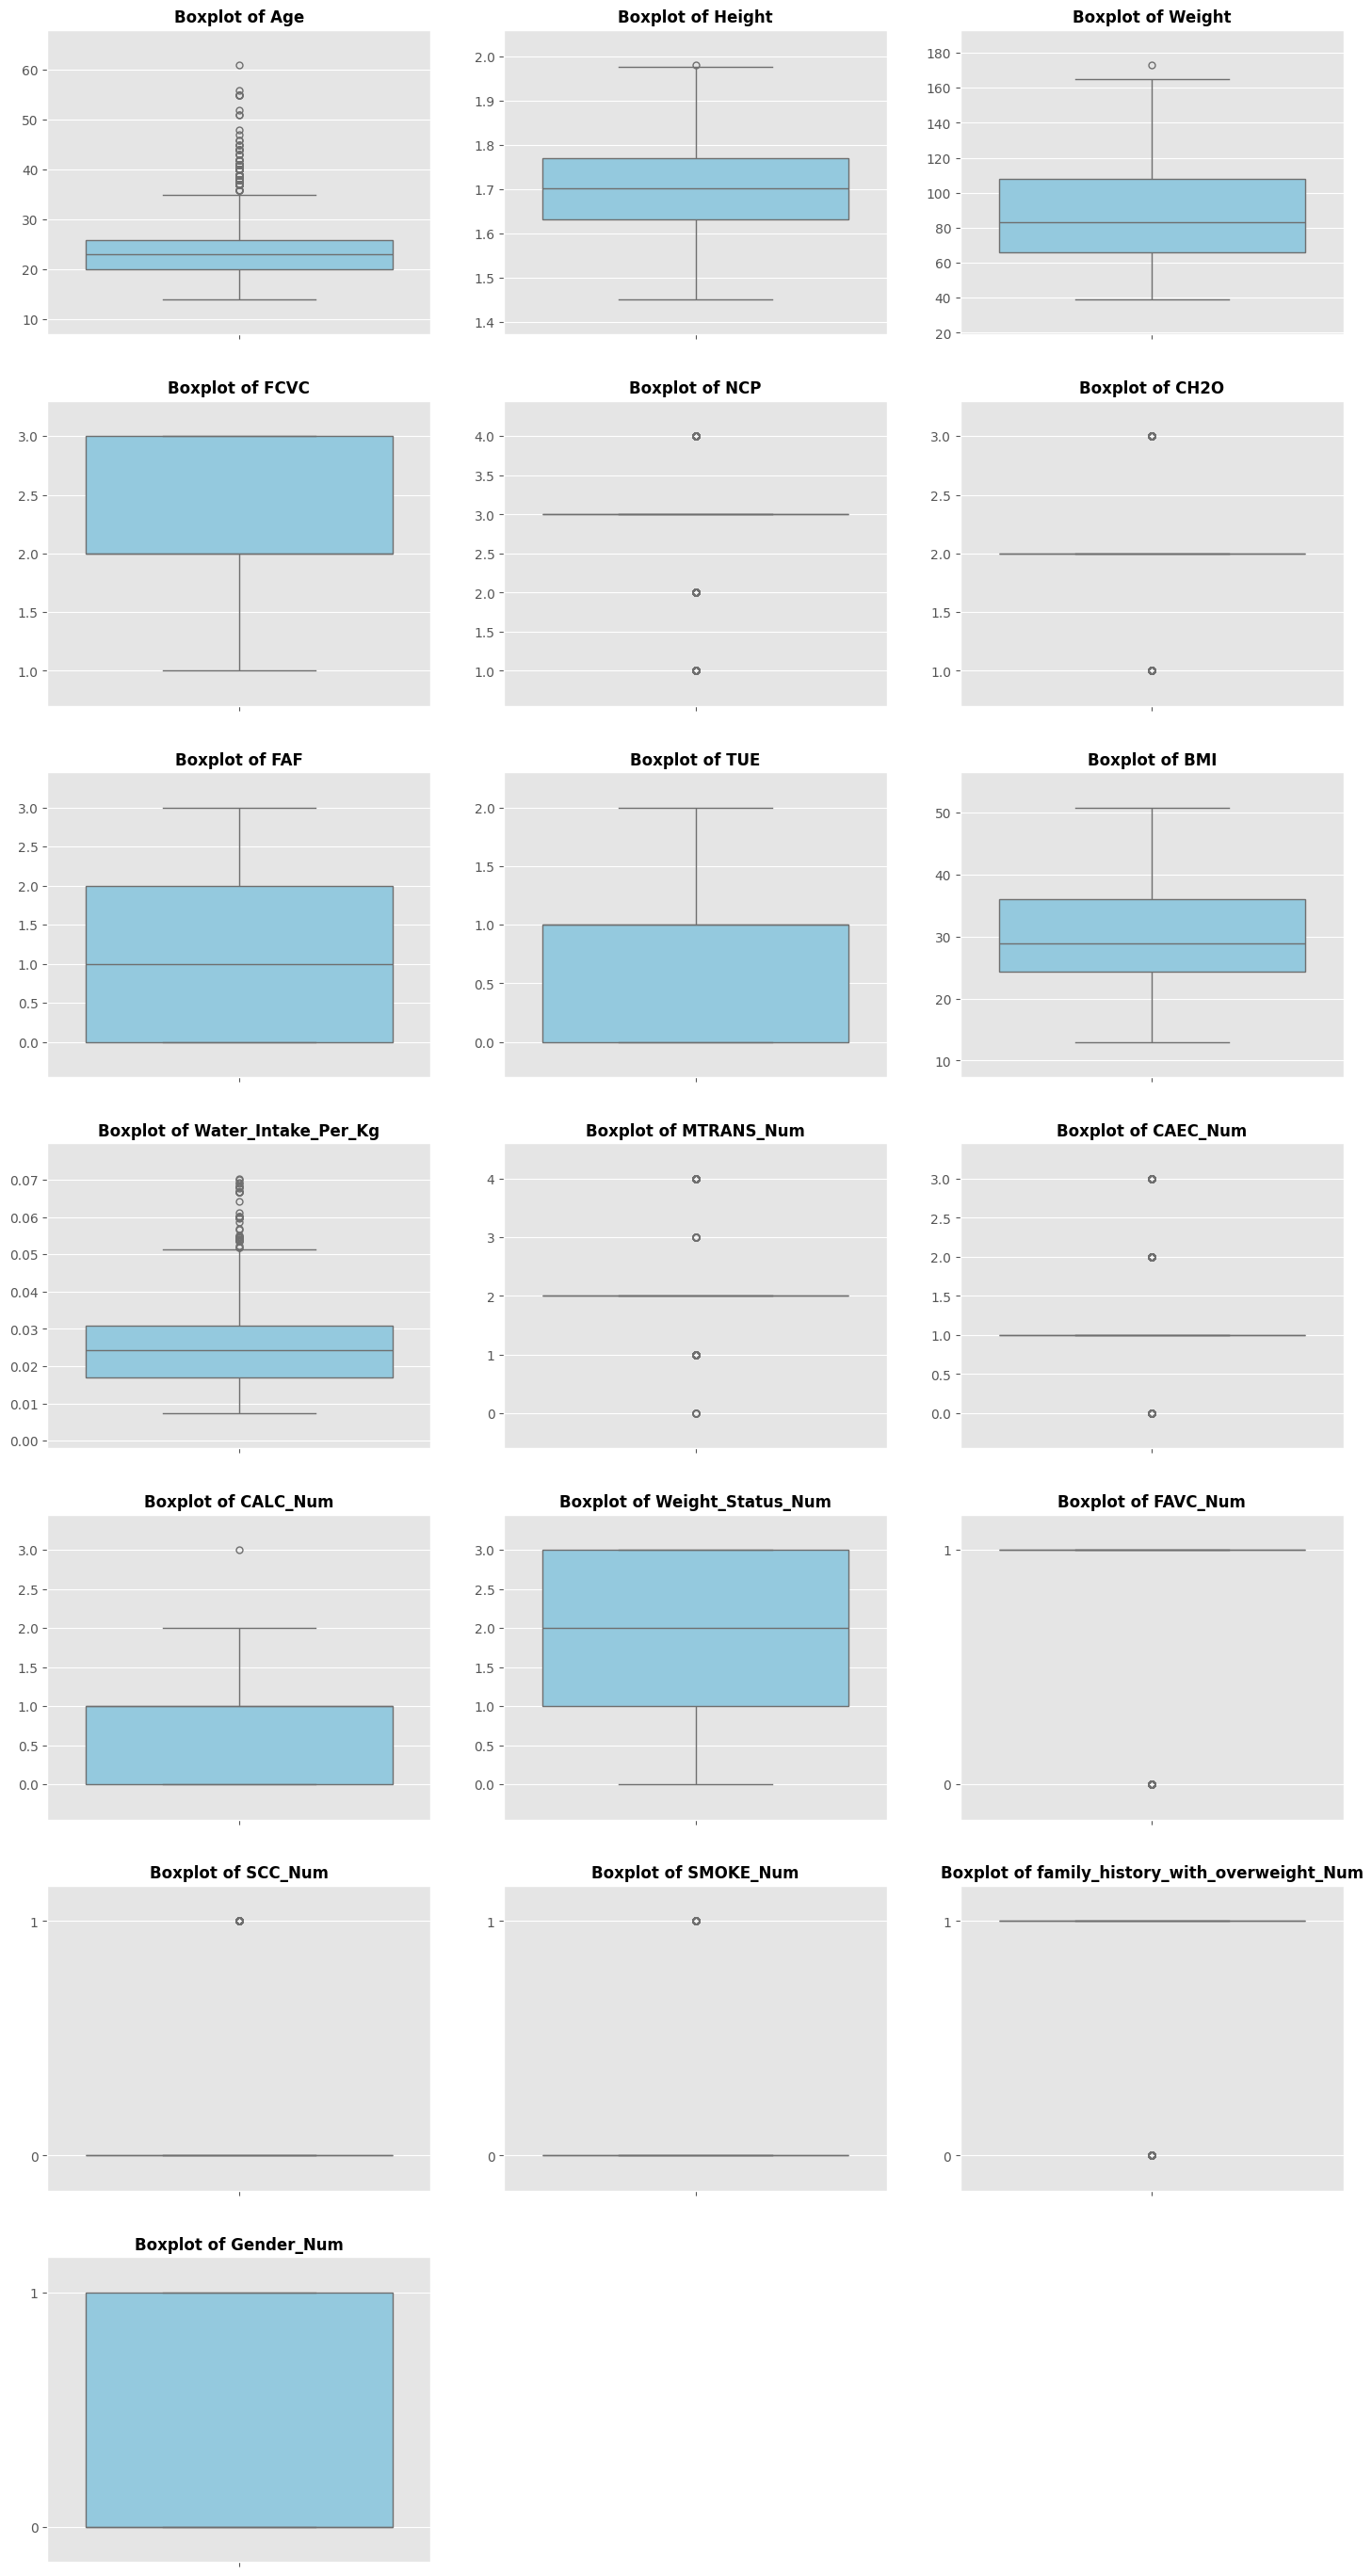

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Pilih kolom numerik
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'int32']).columns
n_cols = len(numeric_cols)

cols_per_row = 3
rows = math.ceil(n_cols / cols_per_row)

# 2. Atur ukuran kanvas dinamis
plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(numeric_cols, 1):
    ax = plt.subplot(rows, cols_per_row, i)
    
    # Plot boxplot
    sns.boxplot(y=df[col], color='skyblue', fliersize=5, ax=ax)
    
    # SET RENTANG Y DINAMIS:
    # Kita ambil nilai min dan max, lalu kasih margin 10% biar nggak nempel garis
    y_min = df[col].min()
    y_max = df[col].max()
    margin = (y_max - y_min) * 0.15 if y_max != y_min else 0.5
    
    # Set limit Y supaya yang cuma 0-1 nggak kelihatan kayak garis doang
    ax.set_ylim(y_min - margin, y_max + margin)
    
    # Kalau datanya cuma 0 dan 1 (Binary), kita paksa tick-nya cuma di 0 dan 1
    if y_min == 0 and y_max == 1:
        ax.set_yticks([0, 1])
    
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    plt.ylabel('')
    plt.tight_layout(pad=3.0)

plt.show()

*Hubungan Fitur Kategorikal dengan Target*

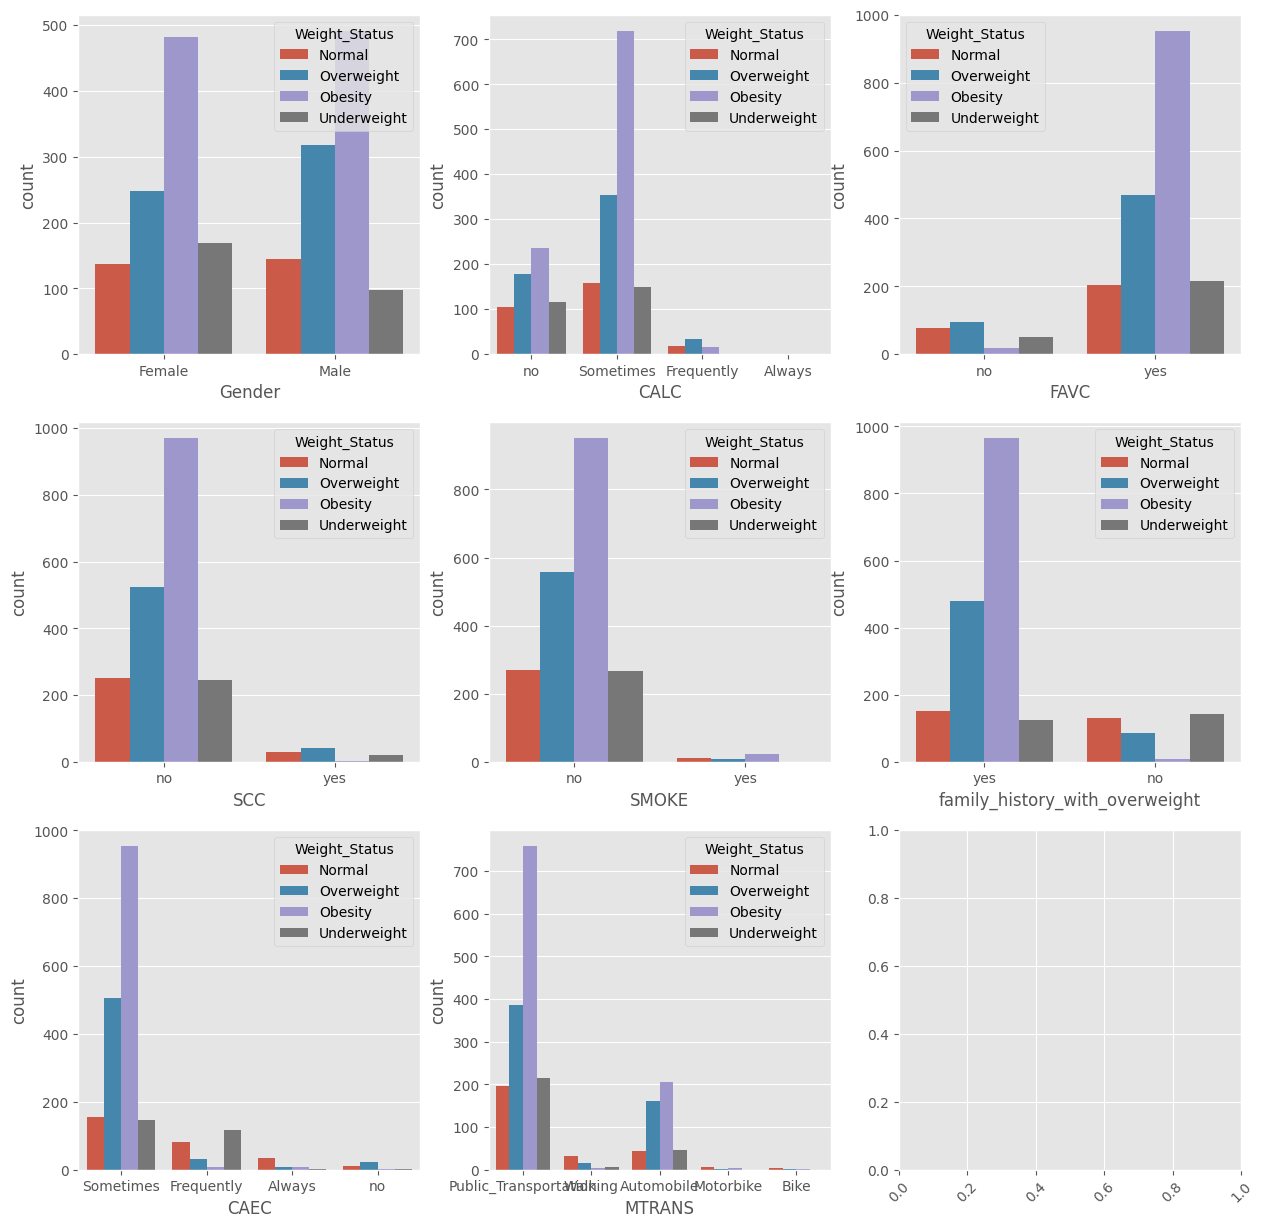

In [75]:
cat_var = ["Gender", "CALC", "FAVC", "SCC", "SMOKE", "family_history_with_overweight", "CAEC", "MTRANS"]

fig, axes = plt.subplots(3,3, figsize=(15,15))
plt.xticks(rotation=45)

for cat, ax in zip(cat_var, axes.flatten()):
    sns.countplot(x=cat, data=df, hue="Weight_Status", ax=ax)

*Insight*
- Konsumsi makanan tinggi kalori (FAVC) terlihat lebih sering muncul pada kategori obesitas.
- Frekuensi konsumsi sayur (FCVC) yang rendah cenderung lebih banyak pada kelompok obesitas.
- Kebiasaan merokok (SMOKE) tidak menunjukkan pengaruh yang terlalu besar terhadap obesitas pada dataset ini.
- Penggunaan transportasi (MTRANS) memperlihatkan bahwa individu yang lebih pasif cenderung berada di kategori overweight/obesitas.

*Analisis Korelasi*

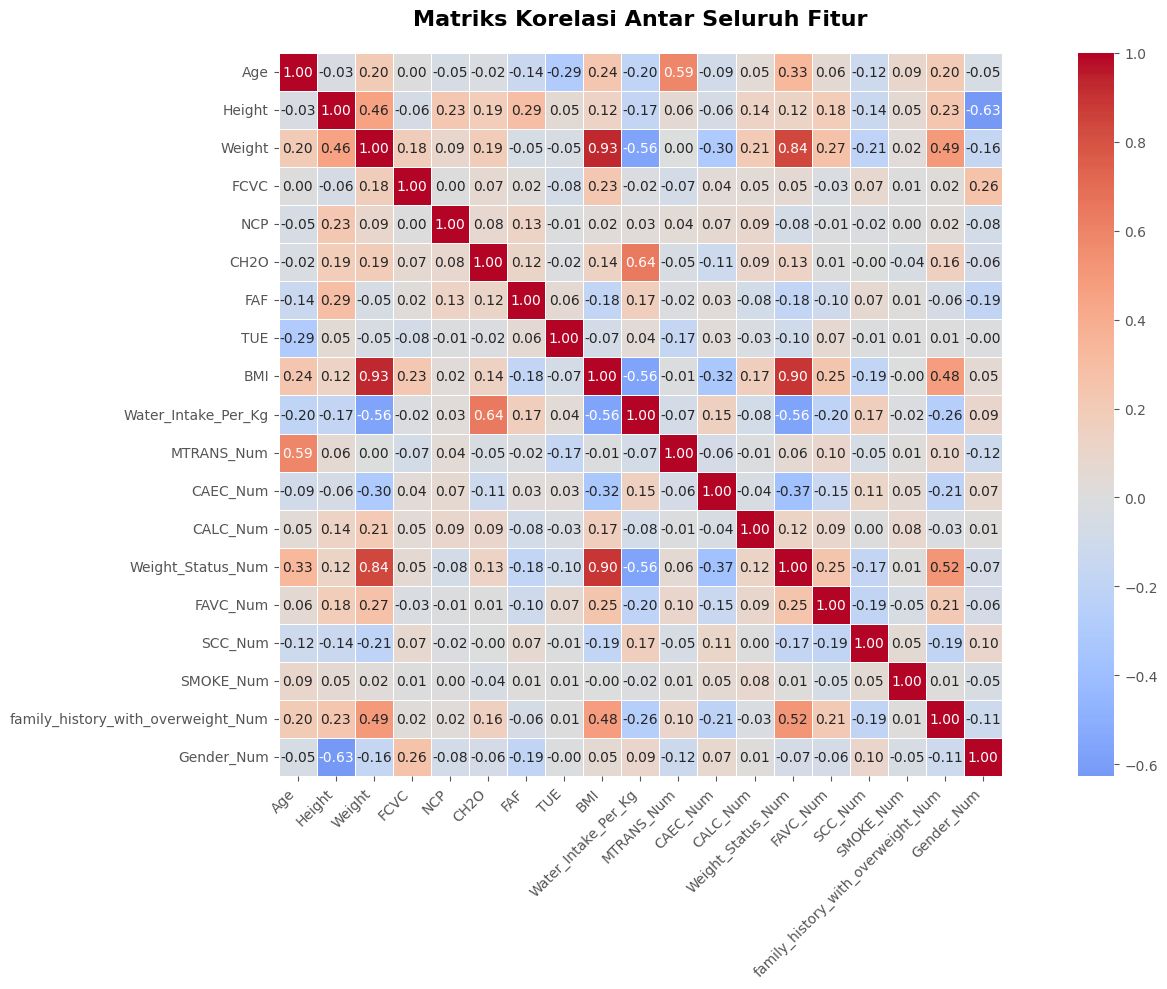

In [76]:
# --- 4. VISUALISASI KORELASI ANTAR FITUR ---
# Hitung matriks korelasi hanya untuk kolom numerik
fitur_angka = df.select_dtypes(include=['number']).columns
corr_matrix = df[fitur_angka].corr()

plt.figure(figsize=(16, 10))

# Membuat heatmap kotak penuh
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0, 
            linewidths=0.5,
            square=True) # Menjaga bentuk sel tetap kotak

plt.title('Matriks Korelasi Antar Seluruh Fitur', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

*Insight*
- Weight memiliki korelasi paling tinggi terhadap obesitas, sehingga berat badan menjadi faktor utama dalam klasifikasi obesitas.
- Height dan Weight memiliki korelasi positif sedang, artinya semakin tinggi seseorang biasanya berat badannya juga meningkat.
- Age memiliki korelasi negatif terhadap TUE (penggunaan teknologi), menunjukkan usia lebih muda cenderung lebih sering menggunakan perangkat teknologi.

*Cek Outlier di Fitur numerik*

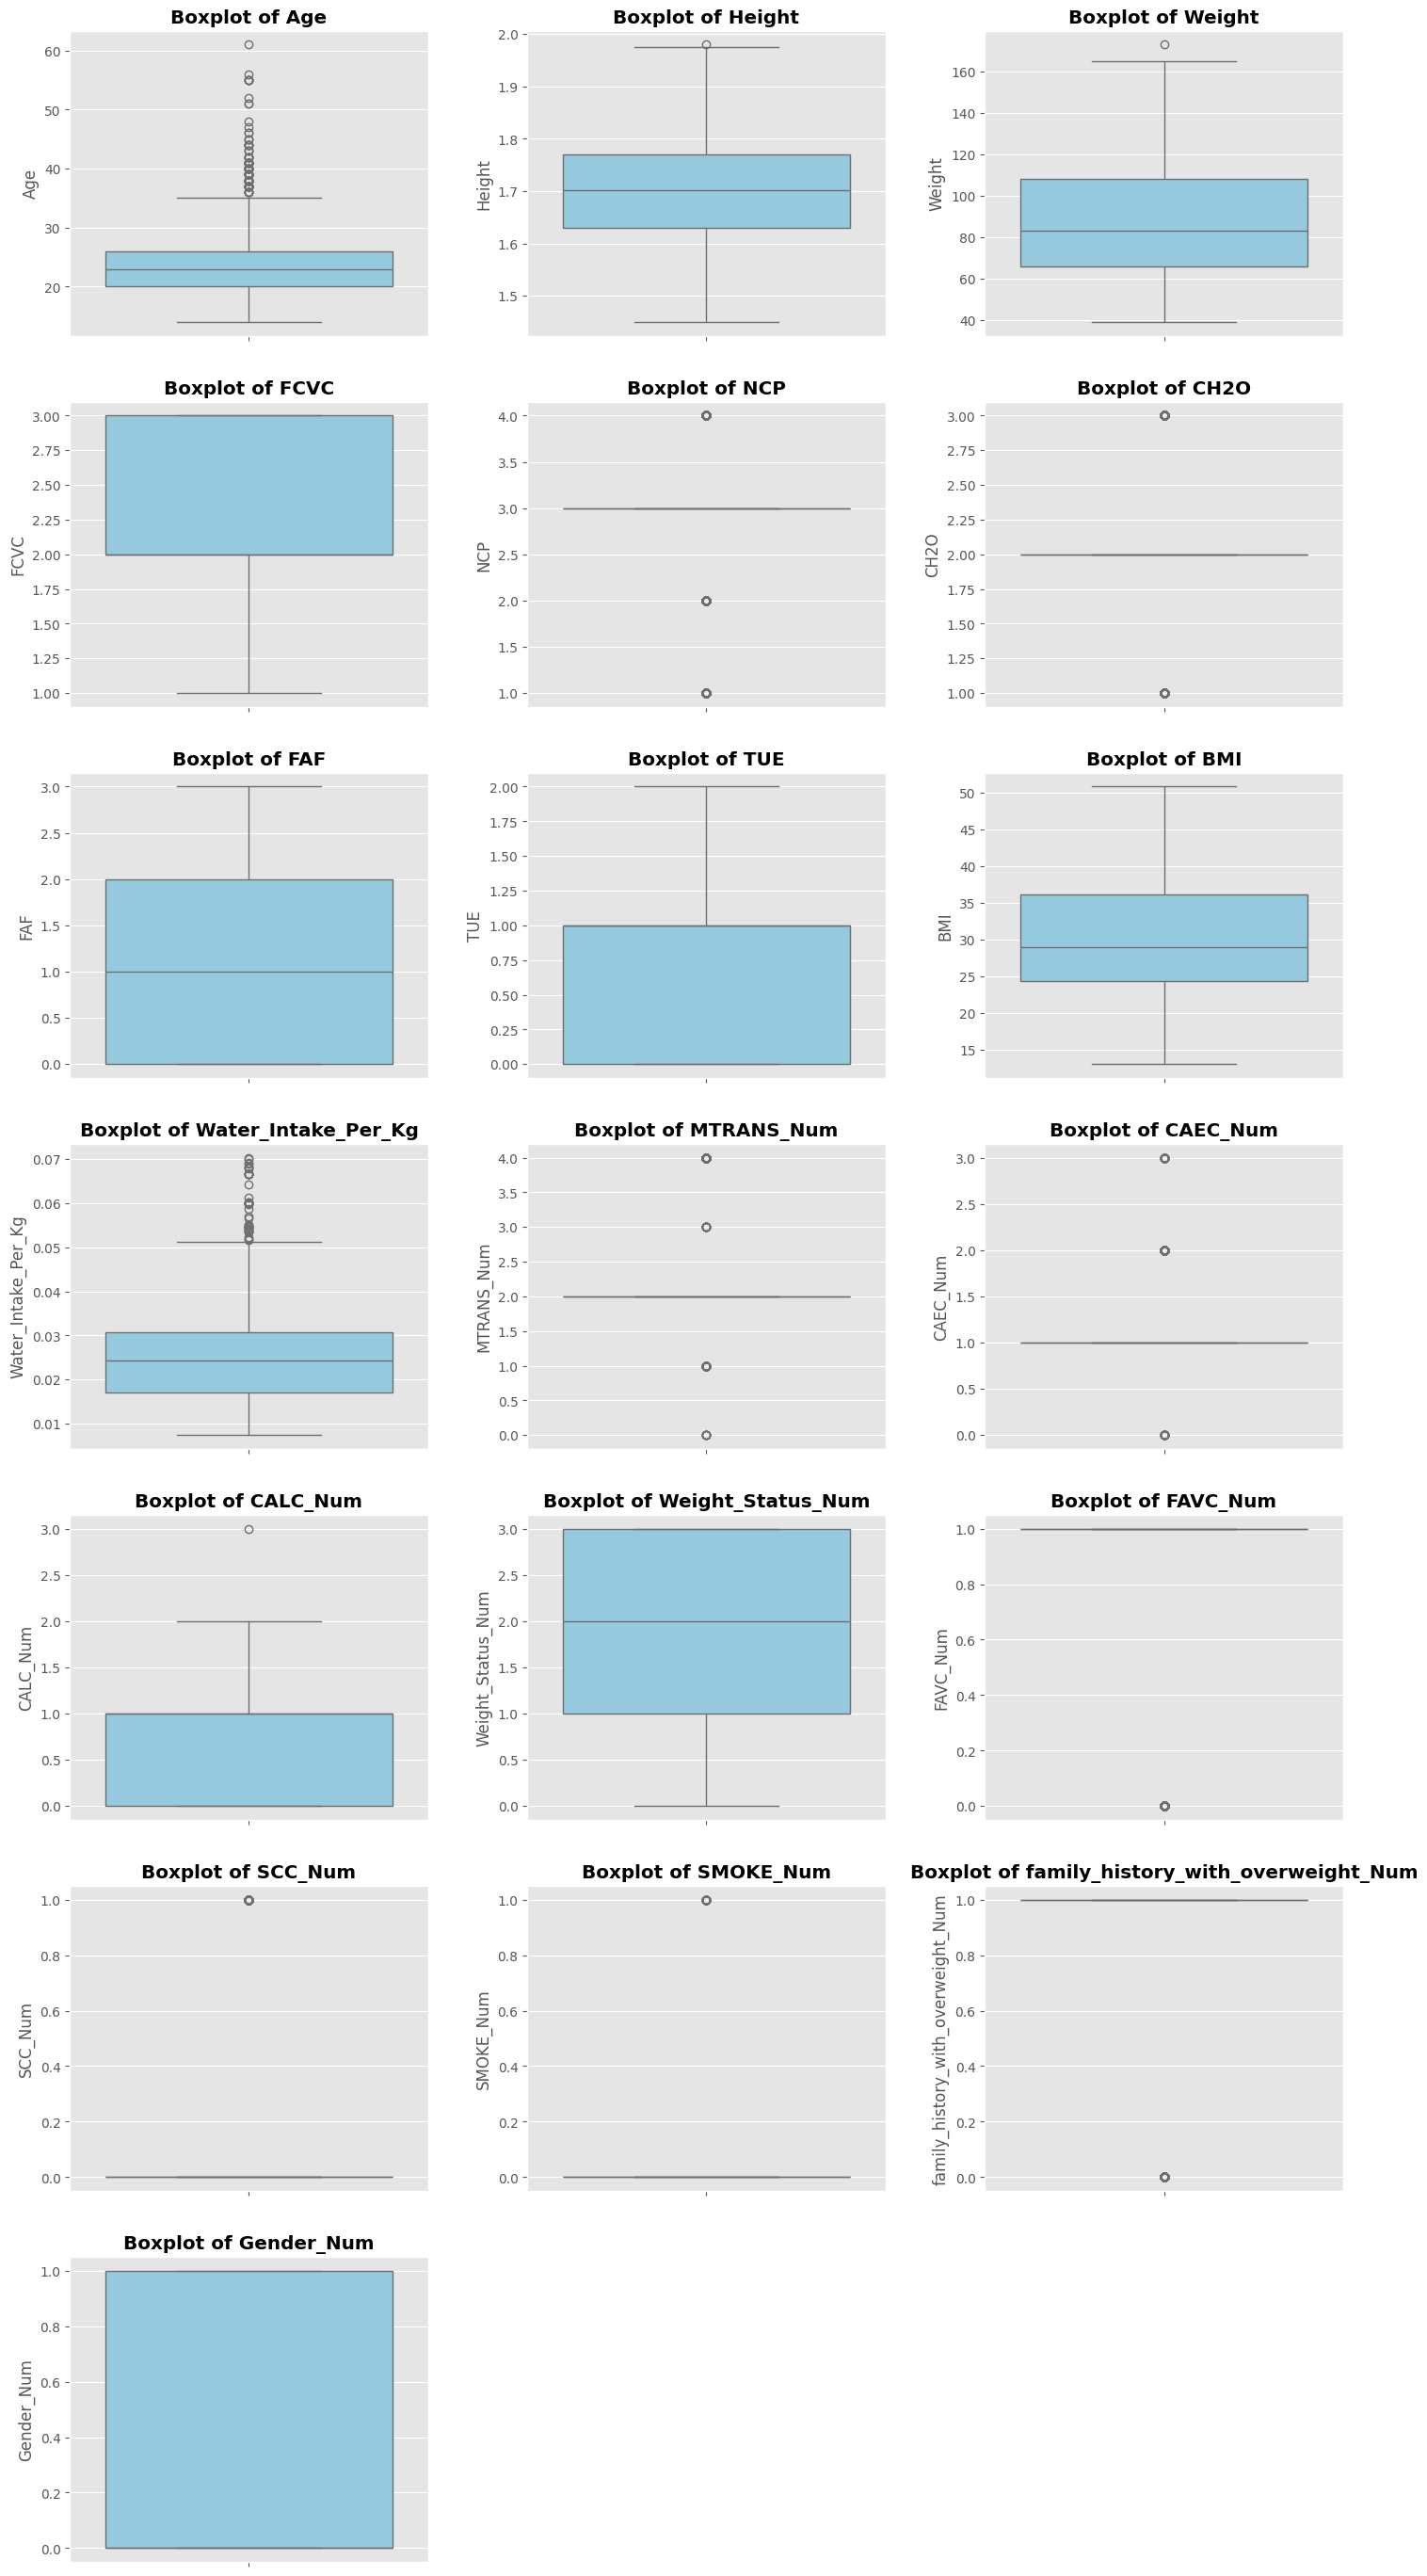

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Pilih kolom numerik (termasuk hasil encoding int32/int64)
numeric_cols = df.select_dtypes(include=['number']).columns
n_cols = len(numeric_cols)

# 2. Tentukan grid (3 kolom per baris)
cols_per_row = 3
rows = math.ceil(n_cols / cols_per_row)

# 3. Atur ukuran kanvas secara DINAMIS (Tinggi = jumlah baris x 4 unit)
plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontweight='bold')
    plt.tight_layout(pad=3.0) # Memberikan jarak antar subplot agar judul tidak tabrakan

plt.show()

# Data Visualization & Explanatory


Pertanyaan 1 : Bagaimana Distribusi Data Kolom Weight_Status Sebagai Target ?

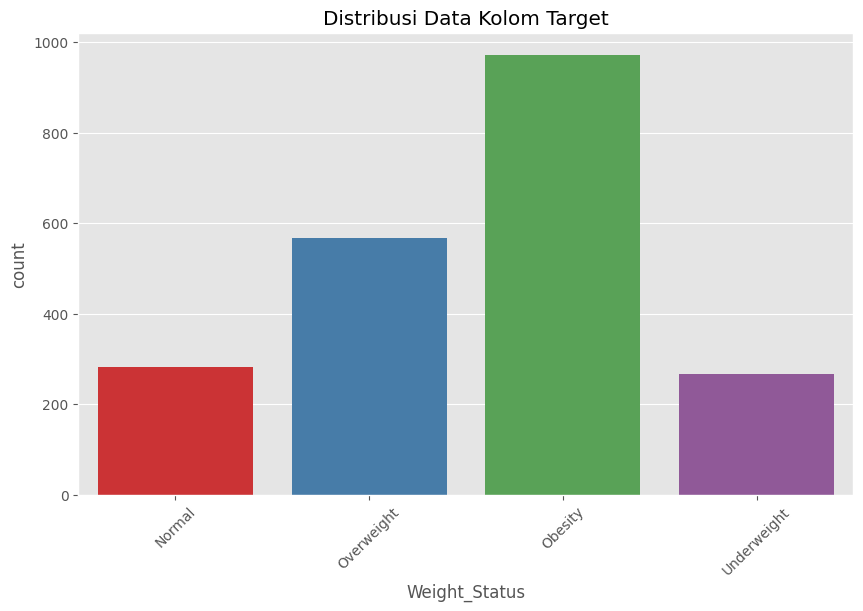

In [78]:
# Distribution of the target variable
plt.figure(figsize=(10, 6))
sns.countplot(x='Weight_Status', data=df, palette='Set1')
plt.title('Distribusi Data Kolom Target')
plt.xticks(rotation=45)
plt.show()

Pertanyaan 2: Hubungan Antara Usia dengan Weight_Status

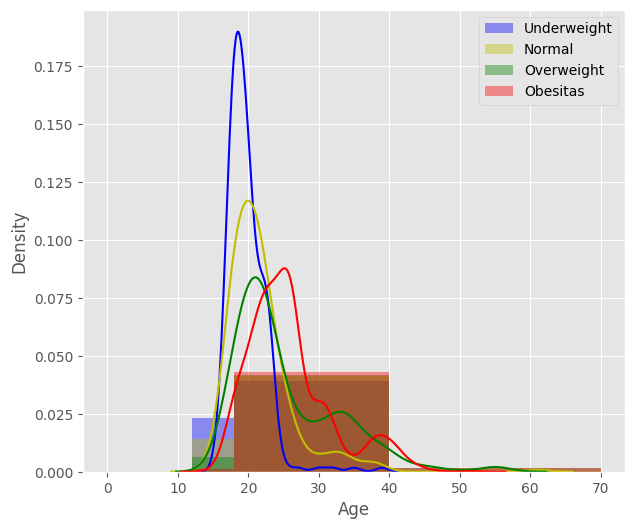

In [79]:
# Hubungan Age dengan Weight_Status
plt.figure(figsize=(7, 6))
sns.distplot(df.Age[df.Weight_Status == 'Underweight'], bins=[0, 5, 12, 18, 40, 70], color="b",label="Underweight" )
sns.distplot(df.Age[df.Weight_Status == 'Normal'], bins=[0, 5, 12, 18, 40, 70], color="y", label="Normal")
sns.distplot(df.Age[df.Weight_Status == 'Overweight'], bins=[0, 5, 12, 18, 40, 70], color="g", label="Overweight")
sns.distplot(df.Age[df.Weight_Status == 'Obesity'], bins=[0, 5, 12, 18, 40, 70], color="r", label="Obesitas")
plt.legend()



Dari visualisasi tersebut dapat dilihat bahwa obesitas dapat dialami oleh usia di atas 25 tahun

Pertanyaan 3: Apa Fitur yang Paling Signifikan dengan Target ?

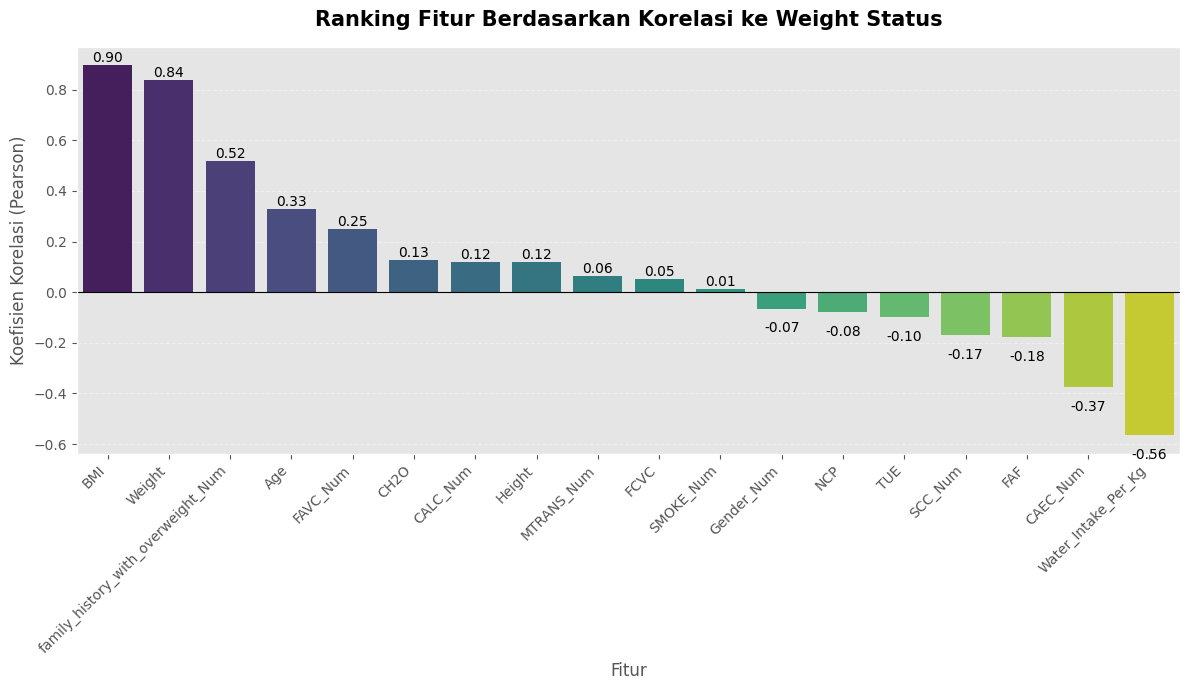

In [80]:
# --- 5. BAR PLOT KORELASI TERHADAP TARGET ---
# Ambil korelasi spesifik ke target, hapus baris target itu sendiri, dan urutkan
target_corr = corr_matrix['Weight_Status_Num'].drop('Weight_Status_Num').sort_values(ascending=False)

plt.figure(figsize=(12, 7))

# Plotting
sns.barplot(x=target_corr.index, 
            y=target_corr.values, 
            hue=target_corr.index, 
            palette='viridis', 
            legend=False)

# Tambahan garis bantu di y=0
plt.axhline(0, color='black', linewidth=0.8)

plt.title('Ranking Fitur Berdasarkan Korelasi ke Weight Status', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Fitur', fontsize=12)
plt.ylabel('Koefisien Korelasi (Pearson)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Tambahkan label nilai di atas bar (opsional tapi sangat membantu)
for i, v in enumerate(target_corr.values):
    plt.text(i, v if v > 0 else v - 0.05, f'{v:.2f}', ha='center', va='bottom' if v > 0 else 'top', fontsize=10)

plt.tight_layout()
plt.show()

*Insight*

3 Fitur paling Signifikan dengan Target Ialah Weight, family_history_with_overweight dan Age


## Splitting Data

In [81]:
from sklearn.model_selection import train_test_split

# Split data utama jadi train dan test dengan proporsi 80:20
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Weight_Status'])

# Drop kolom target di df_test biar murni jadi data buat ujian
df_test.drop(columns=['Weight_Status'], inplace=True)

# Cek hasil split
print(f"Dimensi df_train: {df_train.shape}")
print(f"Dimensi df_test : {df_test.shape}")
print("=" * 50)

# Cek hasil splitting
print("Kolom di df_train:")
print(df_train.columns.tolist())
print("=" * 50)
print("Kolom di df_test:")
print(df_test.columns.tolist())

Dimensi df_train: (1669, 28)
Dimensi df_test : (418, 27)
Kolom di df_train:
['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'Weight_Status', 'BMI', 'Water_Intake_Per_Kg', 'MTRANS_Num', 'CAEC_Num', 'CALC_Num', 'Weight_Status_Num', 'FAVC_Num', 'SCC_Num', 'SMOKE_Num', 'family_history_with_overweight_Num', 'Gender_Num']
Kolom di df_test:
['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'BMI', 'Water_Intake_Per_Kg', 'MTRANS_Num', 'CAEC_Num', 'CALC_Num', 'Weight_Status_Num', 'FAVC_Num', 'SCC_Num', 'SMOKE_Num', 'family_history_with_overweight_Num', 'Gender_Num']


## Data Transformation

### Feature Selection

In [82]:
# 1. Tentukan list fitur yang akan dipertahankan (tanpa target untuk test set)
features_to_keep = [
    'Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF', 
    'family_history_with_overweight_Num', 'CAEC_Num', 
    'FAVC_Num', 'SCC_Num', 'Gender_Num'
]

# 2. Filter df_train (Pertahankan Fitur + Target)
# Kita butuh 'Weight_Status_Num' di train untuk proses belajar model
df_train = df_train[features_to_keep + ['Weight_Status_Num']].copy()

# 3. Filter df_test (Hanya Fitur)
# Kita hanya menyisakan fitur agar formatnya sama dengan input user nanti
df_test = df_test[features_to_keep].copy()

# --- VERIFIKASI AKHIR ---
print("✅ Seleksi Fitur Berhasil!")
print(f"Dimensi df_train: {df_train.shape} (9 Fitur + 1 Target)")
print(f"Dimensi df_test : {df_test.shape} (9 Fitur)")
print("-" * 30)
print("Fitur yang digunakan untuk pelatihan & input user:")
print(df_test.columns.tolist())

✅ Seleksi Fitur Berhasil!
Dimensi df_train: (1669, 10) (9 Fitur + 1 Target)
Dimensi df_test : (418, 9) (9 Fitur)
------------------------------
Fitur yang digunakan untuk pelatihan & input user:
['Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF', 'family_history_with_overweight_Num', 'CAEC_Num', 'FAVC_Num', 'SCC_Num', 'Gender_Num']


In [83]:
df_train

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num,Gender_Num,Weight_Status_Num
1401,39,33.014,0.013,0,1,1.0,1,0,1,3.0
2087,26,41.910,0.027,0,1,1.0,1,0,1,3.0
1324,22,31.988,0.024,0,1,1.0,1,0,1,3.0
664,22,17.906,0.039,0,1,2.0,1,0,1,0.0
835,29,25.912,0.029,2,1,1.0,1,0,1,2.0
...,...,...,...,...,...,...,...,...,...,...
2056,26,41.695,0.027,0,1,1.0,1,0,1,3.0
771,23,25.705,0.026,0,1,2.0,1,0,1,2.0
201,41,33.733,0.013,0,1,3.0,1,0,1,3.0
1765,31,37.498,0.016,1,1,1.0,1,0,0,3.0


In [84]:
df_test

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num,Gender_Num
598,18,17.554,0.039,0,1,1.0,1,0,0
780,20,26.058,0.024,1,1,1.0,1,0,0
1772,25,36.839,0.017,1,1,1.0,1,0,0
2010,26,40.144,0.010,0,1,1.0,1,0,1
311,17,20.957,0.032,3,0,3.0,1,0,0
...,...,...,...,...,...,...,...,...,...
123,24,24.314,0.030,1,1,1.0,1,0,0
1263,38,30.830,0.025,2,1,1.0,1,0,1
384,18,23.437,0.017,0,1,1.0,1,1,1
874,16,25.970,0.029,1,1,1.0,1,0,1


### Normalization

In [85]:
from sklearn.preprocessing import QuantileTransformer
import joblib

# 1. Definisi Scaler menggunakan 'Q'
# Kita buat objeknya dulu
scaler = QuantileTransformer(output_distribution='normal', random_state=42)

# 2. Tentukan kolom yang mau di-scale
columns_to_scale = ['Age', 'BMI', 'FAF', 'Water_Intake_Per_Kg']

# 3. TERAPKAN FIT & TRANSFORM ke dataset
# Scaler "belajar" dari df_train dan langsung mengubah nilainya
df_train_scaled = df_train.copy()
df_train_scaled[columns_to_scale] = scaler.fit_transform(df_train[columns_to_scale])

# 4. TERAPKAN (Hanya TRANSFORM) ke df_test
# Biar konsisten mengikuti standar dari df_train
df_test_scaled = df_test.copy()
df_test_scaled[columns_to_scale] = scaler.transform(df_test[columns_to_scale])

# 5. SIMPAN objek scaler-nya
# Sekarang objek 'scaler' ini sudah punya "ingatan" statistik data lo
joblib.dump(scaler, 'scaler_obesitas.pkl')

print("✅ Scaler sudah diterapkan ke dataset dan berhasil disimpan!")

✅ Scaler sudah diterapkan ke dataset dan berhasil disimpan!


In [86]:
df_train_scaled.describe()

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num,Gender_Num,Weight_Status_Num
count,1669.000,1.669e+03,1.669e+03,1669.000,1669.000,1669.000,1669.000,1669.000,1669.000,1669.000
mean,0.004,-8.063e-05,-7.316e-05,-1.197,0.828,1.140,0.886,0.044,0.493,2.074
std,1.001,1.012e+00,1.012e+00,3.072,0.377,0.454,0.318,0.206,0.500,1.053
min,-5.199,-5.199e+00,-5.199e+00,-5.199,0.000,0.000,0.000,0.000,0.000,0.000
25%,-0.641,-6.746e-01,-6.737e-01,-5.199,1.000,1.000,1.000,0.000,0.000,1.000
50%,0.069,5.532e-04,-5.133e-04,0.038,1.000,1.000,1.000,0.000,0.000,2.000
75%,0.572,6.740e-01,6.738e-01,0.909,1.000,1.000,1.000,0.000,1.000,3.000
max,5.199,5.199e+00,5.199e+00,5.199,1.000,3.000,1.000,1.000,1.000,3.000


In [87]:
df_test_scaled.describe()

,Age,BMI,Water_Intake_Per_Kg,FAF,family_history_with_overweight_Num,CAEC_Num,FAVC_Num,SCC_Num,Gender_Num
count,418.000,418.000,418.000,418.000,418.000,418.000,418.000,418.000,418.000
mean,-0.011,-0.005,0.048,-1.478,0.813,1.172,0.876,0.053,0.507
std,0.991,0.973,1.040,3.054,0.390,0.479,0.330,0.224,0.501
min,-2.575,-2.242,-3.051,-5.199,0.000,0.000,0.000,0.000,0.000
25%,-0.641,-0.677,-0.607,-5.199,1.000,1.000,1.000,0.000,0.000
50%,0.069,-0.052,0.074,0.038,1.000,1.000,1.000,0.000,1.000
75%,0.572,0.647,0.753,0.909,1.000,1.000,1.000,0.000,1.000
max,2.878,2.738,5.199,5.199,1.000,3.000,1.000,1.000,1.000


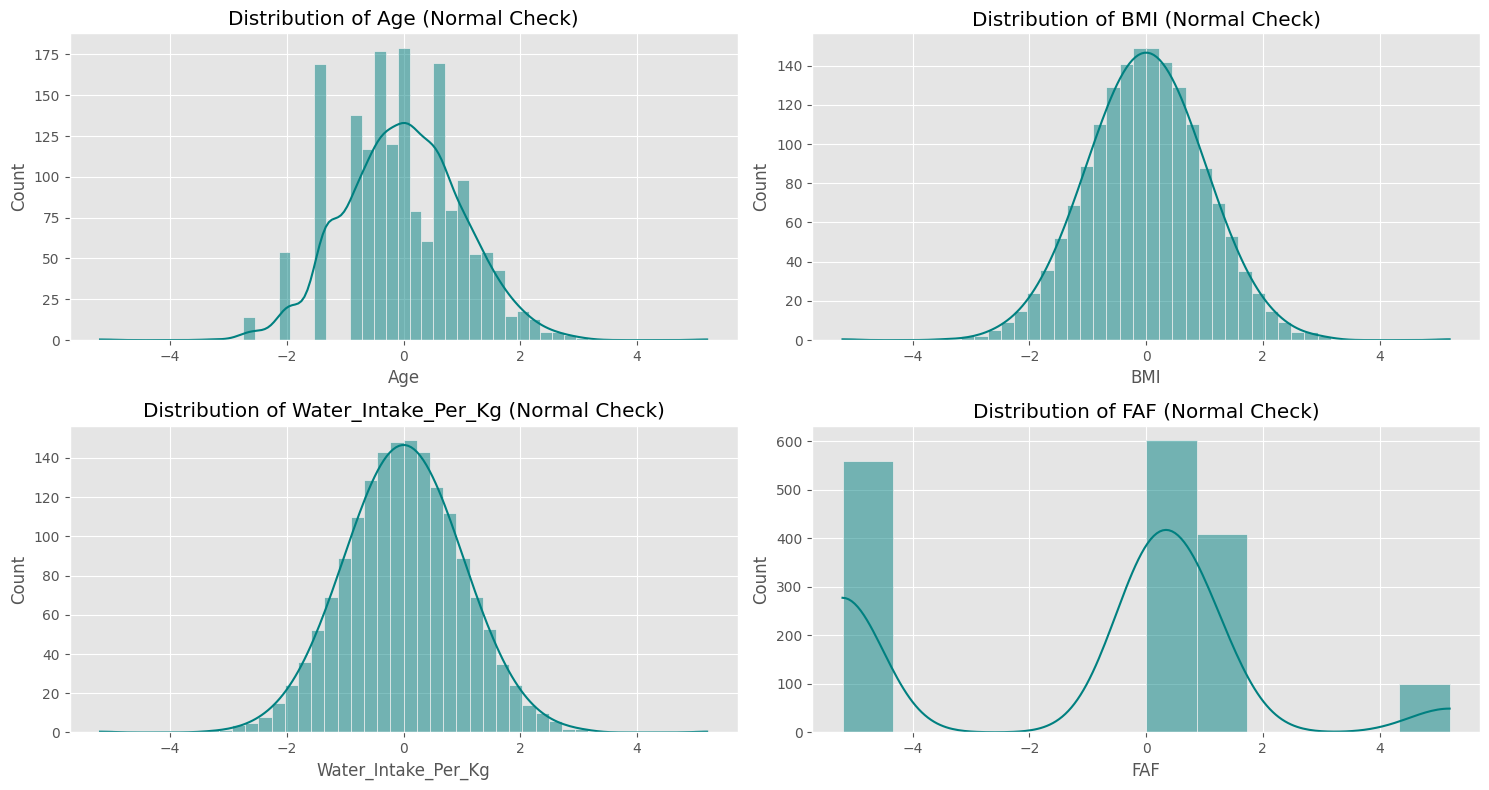

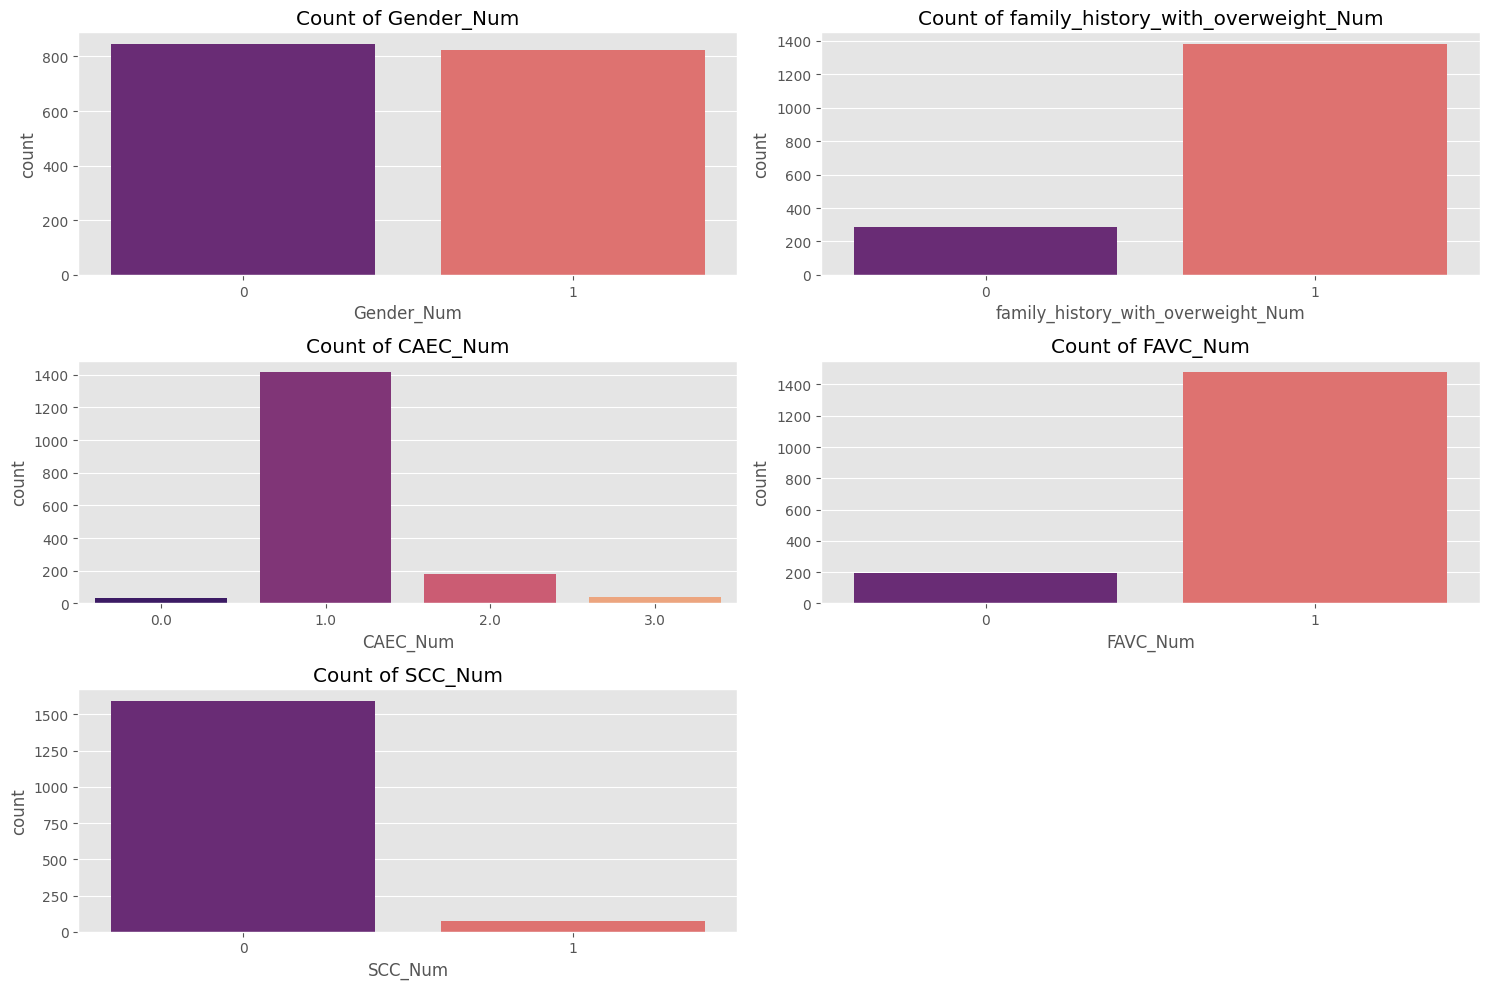

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pisahkan listnya
num_features = ['Age', 'BMI', 'Water_Intake_Per_Kg', 'FAF']
cat_features = ['Gender_Num', 'family_history_with_overweight_Num', 'CAEC_Num', 'FAVC_Num', 'SCC_Num']

# --- PLOT 1: FITUR NUMERIK (Cek Lonceng) ---
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_features):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df_train_scaled[col], kde=True, color='teal')
    plt.title(f'Distribution of {col} (Normal Check)')

plt.tight_layout()
plt.show()

# --- PLOT 2: FITUR KATEGORIKAL (Cek Proporsi 0/1) ---
plt.figure(figsize=(15, 10))
for i, col in enumerate(cat_features):
    plt.subplot(3, 2, i + 1)
    sns.countplot(x=df_train_scaled[col], palette='magma')
    plt.title(f'Count of {col}')

plt.tight_layout()
plt.show()

*Save data hasil scaling dalam format csv*

In [89]:
# Simpan Data Train yang sudah di-scale
df_train_scaled.to_csv('df_train_scaled.csv', index=False)

# Simpan Data Test yang sudah di-scale
df_test_scaled.to_csv('df_test_scaled.csv', index=False)

print("File CSV berhasil disimpan!")

File CSV berhasil disimpan!


## Modeling

## Model Evaluation